In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import polars as pl
import statsmodels.api as sm
from scipy.stats import norm, t

from datetime import datetime, timedelta
from functools import reduce

# data loader
import sys
sys.path.insert(0, '/Users/zzhu/JupyterLab/MarketMaking/_packages')
from tardis_loader import TardisLoader

import nest_asyncio
nest_asyncio.apply()

from dataclasses import dataclass

In [3]:
@dataclass
class DataProcessParas:
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    price_round: int = 2, 
    volume_round: int = 4, 
    latency_gap: int = 5_000, 
    # When handling perps, it could be higher, while dealing with latency cluster, it should be lower. But also need to adjust vol_window and zscore_window correspondly.
    data_span_days: int = 0.5, # Keep the datapoints to be 50-100 (0.5 data_span -> 1 data span) per min. The higher, the more points per min. 50 points seems to be optimal!
    vol_window: int = 100, # 2mins as vol window, don't change
    
    # Step 4: Calculate aggregation features
    feature_windows: list[int] = [15, 30, 60, 90, 150], # Aggregation feature window (better from 0.25min to 2min)
    winsorize_features: list[str] = [], # List of features that require winsorize on total sample
    winsorize_qtl: float = 0.99,
    zscore_windows: list[int] = [75],  # Compare current agg feature with the past zscore_window sample, 1.5min is a good looking back window, don't change
    
    # Step 5: Observation Sampling and Set Target Variable
    beta_vol: float = 2,
    fixed_spread: float = 0.5,
    feature_blind_spot_us: int = 20_000, # Assume we can't use the information happened 20ms from now
    target_blind_spot_us: int = 20_000 # Assume only the vwap change significantly from 20ms ago, we take that as valid trade we may care
    offset: int = -600_000_000 # Used with blind_spot_us together, i.e. past 20ms to 10 min period
    latency_thres: int = 100_000, # 100ms as latency threshold
    
    # Step 6: Linear Regression
    target: str = 'target_return_normalized'
    lr_features: list[str] = ['vwap', 'buy_slippage', 'sell_slippage', 'buy_count', 'buy_volume', 'sell_volume'], # Features that used in linear regression
    merge_col: str = 'local_timestamp' # Col that used to merge target df and feature df

#### Functions

**Step 1: Load data from Tardis**

In [6]:
root_dir = './data'
api_key = 'TD.sSGNjEpohBl9i0FV.zz0-s-b6DZ9c2lt.uoNpgBPGaTITrA9.YlW26JKS0PSfoOG.2pEnnkHAnTpOloD.3wMo'

Tardis_data = TardisLoader(root_dir, api_key)

# Set time and exchanges
start_time = datetime.strptime('2025-03-20', '%Y-%m-%d')
end_time = datetime.strptime('2025-03-26', '%Y-%m-%d')
exchange = 'bybit' #'bybit-spot'
symbol = 'btcusdt'
                    
# Load the data
trades_df = Tardis_data.read(start_time, end_time, data_type='trades', exchange=exchange, symbol=symbol)
bbo_df = Tardis_data.read(start_time, end_time, data_type='book_ticker', exchange=exchange, symbol=symbol)
order_book_25 = Tardis_data.read(start_time, end_time, data_type='book_snapshot_25', exchange=exchange, symbol=symbol)
order_book_10 = order_book_25.select(order_book_25.columns[:45])

# Add Latency Column
trades_df, bbo_df, order_book_25, order_book_10 = [
    ds.with_columns([
        (pl.col('local_timestamp') - pl.col('timestamp')).alias('recv_latency'),
        (pl.col('local_timestamp') - pl.col('timestamp')).shift(-1).alias('next_recv_latency')
    ]).filter(pl.col("next_recv_latency").is_not_null())
    for ds in [trades_df, bbo_df, order_book_25, order_book_10]
]

# Take a look at the data
trades_df.describe()

statistic,human_time,exchange,symbol,timestamp,local_timestamp,id,side,price,amount,recv_latency,next_recv_latency
str,str,str,str,f64,f64,str,str,f64,f64,f64,f64
"""count""","""9147581""","""9147581""","""9147581""",9.147581e6,9.147581e6,"""9147581""","""9147581""",9.147581e6,9.147581e6,9.147581e6,9.147581e6
"""null_count""","""0""","""0""","""0""",0.0,0.0,"""0""","""0""",0.0,0.0,0.0,0.0
"""mean""","""2025-03-23 14:28:28.787812""",null,null,1.7427e15,1.7427e15,null,null,86095.8989,0.057646,45156.403436,45156.403289
"""std""",null,null,null,1.9185e11,1.9185e11,null,null,1492.895181,0.241346,13111.265059,13111.265103
"""min""","""2025-03-19 23:59:59.995000""","""bybit""","""BTCUSDT""",1.7424e15,1.7424e15,"""00000017-cbe4-52f4-ab5f-6364a4…","""buy""",83136.3,0.001,36857.0,36857.0
"""25%""","""2025-03-21 09:11:49.273000""",null,null,1.7425e15,1.7425e15,null,null,84584.1,0.002,40011.0,40011.0
"""50%""","""2025-03-24 03:59:10.180000""",null,null,1.7428e15,1.7428e15,null,null,86404.1,0.013,41135.0,41135.0
"""75%""","""2025-03-25 13:30:37.984000""",null,null,1.7429e15,1.7429e15,null,null,87385.3,0.022,45155.0,45155.0
"""max""","""2025-03-26 23:59:59.436000""","""bybit""","""BTCUSDT""",1.7430e15,1.7430e15,"""fffffe8b-8a6a-5984-82e5-887814…","""sell""",88740.0,128.527,718413.0,718413.0


In [ ]:
ip_binance_perp = trades_df

# binance_perp = trades_df

# bybit_perp_btc = trades_df

# bybit_perp_eth = trades_df

**Step 2: Plot the col distribution, mostly used for calibrate the mapping parameters**

Usage:
1. "rolling_vwap_std" - map 'vwap_std' to 'spread' via a linear function
2. "target_return_normalized" - map 'target_return' to 'feature_skew' via a arctan function

In [179]:
def dist_plot(grouped_df: pl.DataFrame, columns: list[str], min_value: float = float("-inf"), max_value: float = float("inf")) -> None:
    # Convert the 'price' column to a Pandas Series for plotting
    grouped_df = grouped_df.filter(
        pl.col(columns[0]) >= min_value,
        pl.col(columns[0]) <= max_value,
    )
    
    # Calculate number of rows and columns for the subplots (4 per row)
    n_columns = 4  # 4 plots per row
    n_rows = (len(columns) + n_columns - 1) // n_columns  # Calculate required rows
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns * 5, n_rows * 5))
    axes = axes.flatten()  # Flatten the axes to iterate over them
    
    for i, column in enumerate(columns):
        # Convert column to pandas Series for plotting
        data = grouped_df[column].to_pandas()
        
        # Plot histogram on the corresponding subplot
        axes[i].hist(data, bins=40, edgecolor='black')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'{column} Distribution')
    
    # Hide any unused axes if the number of columns isn't a multiple of 4
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

# dist_plot(df, 'rolling_vwap_std')

**Step 3: Group trades and get the single trade feature we need, depends on the exchanges**

**Exchange Details**

1. Bybit: same local timestamp for same bag of trades

In [10]:
def resample_trades_data(raw_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame():
    '''
    Step 1: Resample the raw transcation data into single trade (depends on the rule of exchanges)
    Step 2: Calculate basic features for each single trade, which will be used in aggregation features later
    Step 3: Filter significant trades by volume - to make sure that we always have aroud 100 valid data point per minute
    
    Single Trade Feature: 'vwap', 'volume', 'initial_price'
    Regime Feature (after filter): 'vwap_diff', 'vwap_diff_square'
    '''
    # Access to hyperparameters
    price_round = hyper_params.price_round
    volume_round = hyper_params.volume_round
    latency_gap = hyper_params.latency_gap
    
    # Feature of single trade (volume, vwap)
    grouped_trades = raw_df.with_columns(
        pl.when((pl.col('timestamp').diff() > latency_gap) | (pl.col('side') != pl.col('side').shift())).then(pl.lit(1)).otherwise(0).cum_sum().fill_null(0).alias('bucket_id')
    ).group_by("bucket_id").agg(
        pl.col("human_time").first().alias('start_human_time'),
        pl.col("timestamp").first().alias("start_exch_time"),
        pl.col("timestamp").last().alias("end_exch_time"),
        pl.col("recv_latency").mean(),
        pl.col("price").first().alias("start_price"),
        pl.col("price").last().alias("end_price"),
        pl.col("side").first(),
        ((pl.col("price") * pl.col("amount")).sum() / pl.col("amount").sum()).alias("vwap"),
        pl.col("amount").sum().alias("volume"),
    ).with_columns(
        (pl.col('vwap') - pl.col('start_price')).alias('vwap_slippage'),
    )
        
    # Round digit for specific columns
    grouped_trades = grouped_trades.with_columns(
        pl.col('vwap').round(price_round).alias('vwap'),
        pl.col('volume').round(volume_round).alias('volume')
    ).sort('bucket_id')
        
    return grouped_trades

In [11]:
def filter_trades_data(grouped_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame:
    # Access to hyperparameter
    data_span_days = hyper_params.data_span_days
    vol_window = hyper_params.vol_window
    
    # Choose the volume threshold to make that we can have 100 valid trade per minute on average
    min_sample_ratio = (data_span_days * 1440 * 100) / grouped_df.shape[0] # baseline - 100 trades per minute
    volume_threshold = grouped_df.select(pl.col("volume").quantile(1 - min_sample_ratio)).to_numpy()[0][0]
    print(f'volume_threshold: {volume_threshold}')
    
    # Feature of vwap diff between filtered data points - Used for vol calculation
    filtered_trades = grouped_df.filter(
        pl.col("volume") >= volume_threshold
    ).with_columns(
        (((pl.col('vwap').diff())/pl.col('vwap')*10000)).alias('vwap_diff'),
        (((pl.col('vwap').diff())/pl.col('vwap')*10000).pow(2)).alias('vwap_diff_square'),
    ).drop_nulls().with_row_index().with_columns(
        pl.mean("vwap_diff_square").rolling(index_column="index", period=f"{vol_window}i").pow(0.5).alias(f'rolling_vwap_std')
    )
    
    return filtered_trades.sort('index').drop('index')

**Step 4: Calculate aggregation features**

In [13]:
def agg_feature(filtered_df: pl.DataFrame, hyper_params: DataProcessParas, feature_window: int) -> pl.DataFrame:
    '''
    Calculate the aggregation features and drop outliers via winsorize
    
    Features: "vwap_diff_sum", "buy_count_ratio", "vwap"
    
    Features that need to be winsorized: ""
    '''
    # Access to hyperparamters
    winsorize_features = hyper_params.winsorize_features
    winsorize_qtl = hyper_params.winsorize_qtl
    feature_blind_spot_us = hyper_params.feature_blind_spot_us
    offset = hyper_params.offset
    lr_features = hyper_params.lr_features + ['bucket_id']
        
    # Calculate the agg features using the datapoint that are out of blind spot period (index_column="index", offset=f"{-feature_window}i", period=f"{feature_window}i")'
    # Use end_exch_time is more strictly, means we couldn't use the information within the same large trade. (which kind make sense as well)
    agg_feature_df = filtered_df.with_row_index().rolling(index_column="end_exch_time", offset=f'{offset}i', period=f'{-feature_blind_spot_us-offset}i').agg(
        pl.len().alias("sample_num"),
        
        # vwap related
        pl.col('vwap').tail(feature_window).last().alias('vwap'),
        pl.col('vwap').tail(feature_window).first().alias('first_vwap'),
        
        # volume related
        pl.col('volume').tail(feature_window).sum().alias('volume'),
        pl.col('volume').tail(feature_window).filter(pl.col('side').tail(feature_window) == 'buy').sum().alias('buy_volume'),
        pl.col('volume').tail(feature_window).filter(pl.col('side').tail(feature_window) == 'sell').sum().alias('sell_volume'),
        
        # misc
        pl.col('side').tail(feature_window).filter(pl.col('side').tail(feature_window) == 'buy').count().alias('buy_count'),
        pl.col('vwap_slippage').tail(feature_window).filter(pl.col('side').tail(feature_window) == 'buy').sum().alias('buy_slippage'),
        pl.col('vwap_slippage').tail(feature_window).filter(pl.col('side').tail(feature_window) == 'sell').sum().alias('sell_slippage'),
        
    ).with_columns(
        # Attach the bucket_id back
        filtered_df['bucket_id'].alias('bucket_id'),
        
        # Complex agg features that rely on previous basic agg features
        (((pl.col('first_vwap') - pl.col('vwap')).pow(2))/ pl.col('volume')).alias('book_impact'),
    )
    
    # Drop data which has less data points than feature window (mostly at warm-up period)
    agg_feature_df = agg_feature_df.filter(pl.col('sample_num') >= feature_window)
    
    # Drop outliers via winsorize over entire sample
    for feature in winsorize_features:
        up_limit = agg_feature_df[feature].quantile(winsorize_qtl)
        agg_feature_df = agg_feature_df.with_columns(
            pl.when(pl.col(feature) >= up_limit).then(up_limit).otherwise(pl.col(feature)).alias(feature),
        )
    
    return agg_feature_df.select(lr_features)

In [14]:
def rolling_zscore(agg_df: pl.DataFrame, zscore_window: int) -> pl.DataFrame:
    '''
    Calculate the rolling z-score of features.
    
    Default: All features will be replaced by their rolling z-score
    '''
    zscore_df = agg_df.with_row_index().rolling(index_column="index", period=f"{zscore_window}i").agg(
        pl.col('bucket_id').last(),
        *[((pl.col(col).last() - pl.col(col).mean()) / pl.col(col).std()).alias(col) for col in agg_df.columns if col != "bucket_id"]
    )
    
    # Drop data in the warm-up period
    zscore_df = zscore_df[zscore_window:]
    
    return zscore_df

In [262]:
def rolling_rv(agg_df: pl.DataFrame, ema_alpha: int=0.98) -> pl.DataFrame:
    '''
    Calculate the rolling val/ema(val)
    
    Default: All features will be replaced by their rolling z-score
    '''
    min_samples = 100
    rv_df = agg_df.select(
        pl.col('bucket_id'),
        *[(pl.col(col) / pl.col(col).ewm_mean(alpha=ema_alpha, adjust=False)).alias(col) for col in agg_df.columns if col != "bucket_id"]
    )
    
    # Drop data in the warm-up period
    rv_df = rv_df[min_samples:]
    
    return rv_df

**Step 5: Observation Sampling and Set Target Variable**

In [16]:
def ob_stv(grouped_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame:
    '''
    Step 1: Filtering the samples that we care (where we more likely to trade)
    
    Step 2: Set a apropriate target variable - vwap diff between current significant trade and next opposite significant trade 
    
    Step 3: Normalize the target variable with rolling vwap std (which is also required by production)
    
    Step 4: Filter out high latency data points
    '''
    # Access to hyperparamters
    beta_vol = hyper_params.beta_vol
    fixed_spread = hyper_params.fixed_spread
    target_blind_spot_us = hyper_params.target_blind_spot_us
    latency_thres = hyper_params.latency_thres
    offset = hyper_params.offset
    
    # Step 1: Valid vwap diff should meet such condition: last trade should be the most recent one happened at least {target_blind_spot} ms before
    target_df = grouped_df.with_columns(
        pl.last("vwap").rolling(index_column="end_exch_time", offset=f'{offset}i', period=f'{-target_blind_spot_us-offset}i').alias(f'rolling_{int(target_blind_spot_us/1000)}ms_vwap')
    ).drop_nulls().with_columns(
        ((pl.col('vwap') - pl.col(f'rolling_{int(target_blind_spot_us/1000)}ms_vwap')) / pl.col('vwap') * 10_000).alias('valid_vwap_diff')
    )
    
    # It's more accurate to calculate the valid vwap diff before volume filtering!
    target_df = filter_trades_data(target_df, hyper_params)
    
    # Step 2.1: Calculate the spread we will set in production, to filter the significant trade we most care about
    target_df = target_df.with_columns(
        (pl.col("rolling_vwap_std") * beta_vol + fixed_spread).alias('prod_spread')
    ).filter(
        (pl.col('valid_vwap_diff').abs() >= pl.col('prod_spread'))
    )
        
    # Step 2.2: Calculate the target varible: current_vawp - next_opposite_trade_vwap
    target_df = target_df.with_columns(
        (pl.when(pl.col('side') == 'sell').then(pl.lit(0)).otherwise(pl.lit(1)).diff().abs().cum_sum().fill_null(0)).alias('target_bucket_id')
    )
    
    # Step 2.3: Get the next opposite trade vwap
    target_df_2 = target_df.select(
        (pl.col('target_bucket_id') - 1).alias('target_bucket_id'),
        pl.col('vwap').alias('vwap')
    ).group_by('target_bucket_id').agg(
        pl.col('vwap').first().alias('next_trade_price')
    )
    
    # Step 2.4: Merge it back to original df, then we can get our target variable
    target_df = target_df.join(target_df_2, on='target_bucket_id', how='left').drop_nulls().with_columns(
        ((pl.col('vwap') - pl.col('next_trade_price')) / pl.col('vwap') * 10000).alias('target_return_bps')
    )
    
    # Step 3: Normalize target variable with rolling vwap std
    target_df = target_df.with_columns(
        (pl.col('target_return_bps') / pl.col('rolling_vwap_std')).alias('target_return_normalized')
    )
    
    # Step 4: Final filter - filter out repetition samples which are too close to each other and high latency samples
    target_df = target_df.filter(
        pl.col('end_exch_time').diff() >= target_blind_spot_us,
        pl.col('recv_latency') <= latency_thres
    )
    
    return target_df

**Step 6: Linear Regression**

In [18]:
def linreg(target_df: pl.DataFrame, feature_df: pl.DataFrame, hyper_params: DataProcessParas) -> None:
    '''
    Run the linear regression
    '''
    # Access to hyperparamters
    target = hyper_params.target
    feature_list = hyper_params.lr_features
    
    lr_df = target_df.select(
        pl.col('bucket_id'),
        pl.col(target)
    ).join(feature_df, on='bucket_id', how='inner').drop_nulls()
    
    df = lr_df.to_pandas()

    # Define the feature columns and the target column
    X = df[feature_list]  # Feature columns
    y = df[target]  # Target column

    # Add a constant column (intercept) to the feature columns for statsmodels
    X = sm.add_constant(X)

    # Run regression and print result
    model = sm.OLS(y, X).fit()
    print(model.summary())
        
    # Plot histogram
    plt.hist(model.fittedvalues, bins=40, edgecolor='black')  # Adjust bins as needed
    plt.xlabel('Predicited Target')
    plt.ylabel('Frequency')
    plt.show()
    
    return lr_df

#### Regression Test - BTC

In [234]:
hyper_paras = DataProcessParas(
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    price_round = 2,
    volume_round = 4,
    latency_gap = 1_000,
    # When handling perps, it could be higher, while dealing with latency cluster, it should be lower. But also need to adjust vol_window and zscore_window correspondly.
    data_span_days = 3.5, # Keep the datapoints to be 50-100 (0.5 data_span -> 1 data span) per min. The higher, the more points per min. 50 points seems to be optimal!
    vol_window = 100, # 2mins as vol window, don't change
    
    # Step 4: Calculate aggregation features
    feature_windows = [25], # agg feature window, can consider use average of different window value
    winsorize_features = [],
    winsorize_qtl = 0.99,
    zscore_windows = [100], # Compare current agg feature with the past zscore_window sample, seems 150 is a good number, don't change. (i.e. 1.5min)
    
    # Step 5: Observation Sampling and Set Target Variable
    beta_vol = 1,
    fixed_spread = 0.25, # 0.5 basic bps and 0.25 min update bps, so 0.5 - 0.25 = 0.25
    feature_blind_spot_us = 20_000,
    target_blind_spot_us = 25_000,
    offset = -3600_000_000, # Used with blind_spot_us together, i.e. past 20ms to 30 min period
    latency_thres = 100_000,
    
    # Step 6: Linear Regression
    target = 'target_return_normalized',
    lr_features = ['buy_slippage', 'sell_slippage', 'buy_volume', 'sell_volume', 'vwap'], # Candidates: ['vwap', 'buy_count']
)

volume_threshold: 0.094


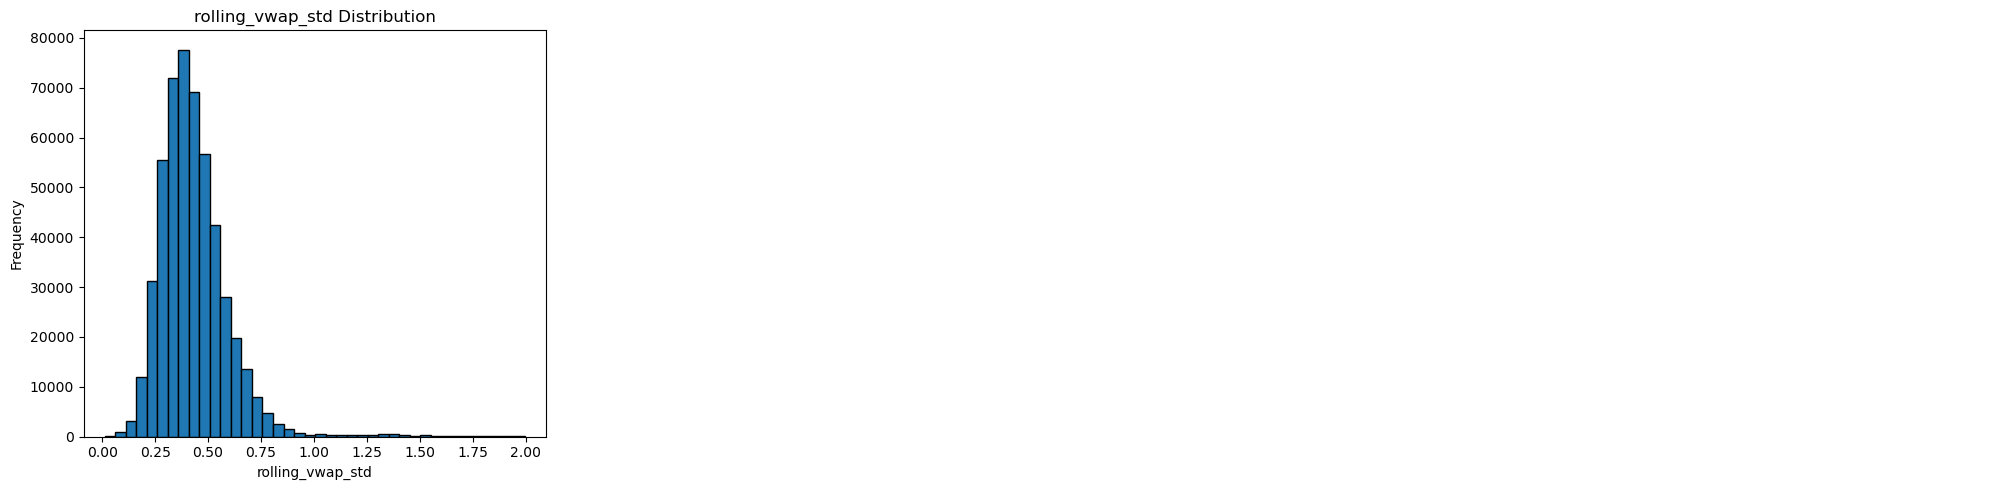

In [236]:
grouped_df = resample_trades_data(bybit_perp_btc, hyper_paras)
filtered_df = filter_trades_data(grouped_df, hyper_paras)
dist_plot(filtered_df.filter(pl.col('rolling_vwap_std') <= 2), ['rolling_vwap_std'])

In [238]:
avg_zscore_df = pl.DataFrame()
for feature_window in hyper_paras.feature_windows:
    feature_df = agg_feature(filtered_df, hyper_paras, feature_window)
    for zscore in hyper_paras.zscore_windows:
        zscore_df = rolling_zscore(feature_df, zscore)

        zscore_df = zscore_df.drop('index')

        if avg_zscore_df.height == 0:
            avg_zscore_df = zscore_df
        else:
            avg_zscore_df = avg_zscore_df.join(zscore_df, on="bucket_id", how="inner", suffix="_df2").select(
                pl.col("bucket_id"),
                *[(pl.col(col) + pl.col(f"{col}_df2")).alias(col) for col in avg_zscore_df.columns if col != "bucket_id"]
            )

# Divided by feature windows length
sample_nums = len(hyper_paras.feature_windows) * len(hyper_paras.zscore_windows)
avg_zscore_df = avg_zscore_df.select(
    pl.col("bucket_id"),
    *[pl.col(col) / sample_nums for col in avg_zscore_df.columns if col != "bucket_id"]
)

# # Doing clipping
# for feature in zscore_df.columns:
#     if feature == 'bucket_id':
#         continue
#     upper_limit = 3
#     lower_limit = -3
#     avg_zscore_df = avg_zscore_df.with_columns(
#         pl.when(pl.col(feature) >= upper_limit).then(upper_limit)
#         .when(pl.col(feature) <= lower_limit).then(lower_limit)
#         .otherwise(pl.col(feature)).alias(feature),
#     )

prev_length = avg_zscore_df.height

# Doing droping
for feature in zscore_df.columns:
    if feature == 'bucket_id':
        continue
    upper_limit = 20
    lower_limit = -20
    avg_zscore_df = avg_zscore_df.filter(
        pl.col(feature) <= upper_limit,
        pl.col(feature) >= lower_limit
    )

drop_nums = prev_length - avg_zscore_df.height
print(f'drop {drop_nums} outliers out of {prev_length} samples')

drop 802 outliers out of 505885 samples


In [272]:
filtered_df.join(feature_df, on='bucket_id', how='left')[:1000].to_pandas().to_csv('test.csv')

In [268]:
feature_df[100:]

buy_slippage,sell_slippage,buy_volume,sell_volume,vwap,bucket_id
f64,f64,f64,f64,f64,i32
0.133333,-28.089921,3.132,14.633,86827.7,536
1.267243,-28.089921,3.602,14.633,86828.83,537
1.267243,-28.089921,3.468,16.936,86836.2,538
1.267243,-28.089921,4.323,16.936,86836.3,542
1.267243,-24.991561,4.904,16.814,86854.4,562
…,…,…,…,…,…
0.009889,0.0,25.03,1.269,86848.8,2229883
0.009889,0.0,23.83,1.269,86848.9,2229884
0.237136,0.0,22.175,1.269,86850.53,2229887


In [264]:
rolling_rv(feature_df, 0.98)

bucket_id,buy_slippage,sell_slippage,buy_volume,sell_volume,vwap
i32,f64,f64,f64,f64,f64
536,1.0,1.0,1.000183,0.999997,1.0
537,1.018222,1.0,1.00262,1.0,1.0
538,1.000358,1.0,0.999282,1.002727,1.000002
542,1.000007,1.0,1.00396,1.000054,1.0
562,1.0,0.997527,1.002445,0.999856,1.000004
…,…,…,…,…,…
2229883,1.0,-0.0,0.999968,0.993038,1.0
2229884,1.0,-0.0,0.998993,0.99986,1.0
2229887,1.01954,-0.0,0.998488,0.999997,1.0


volume_threshold: 0.094


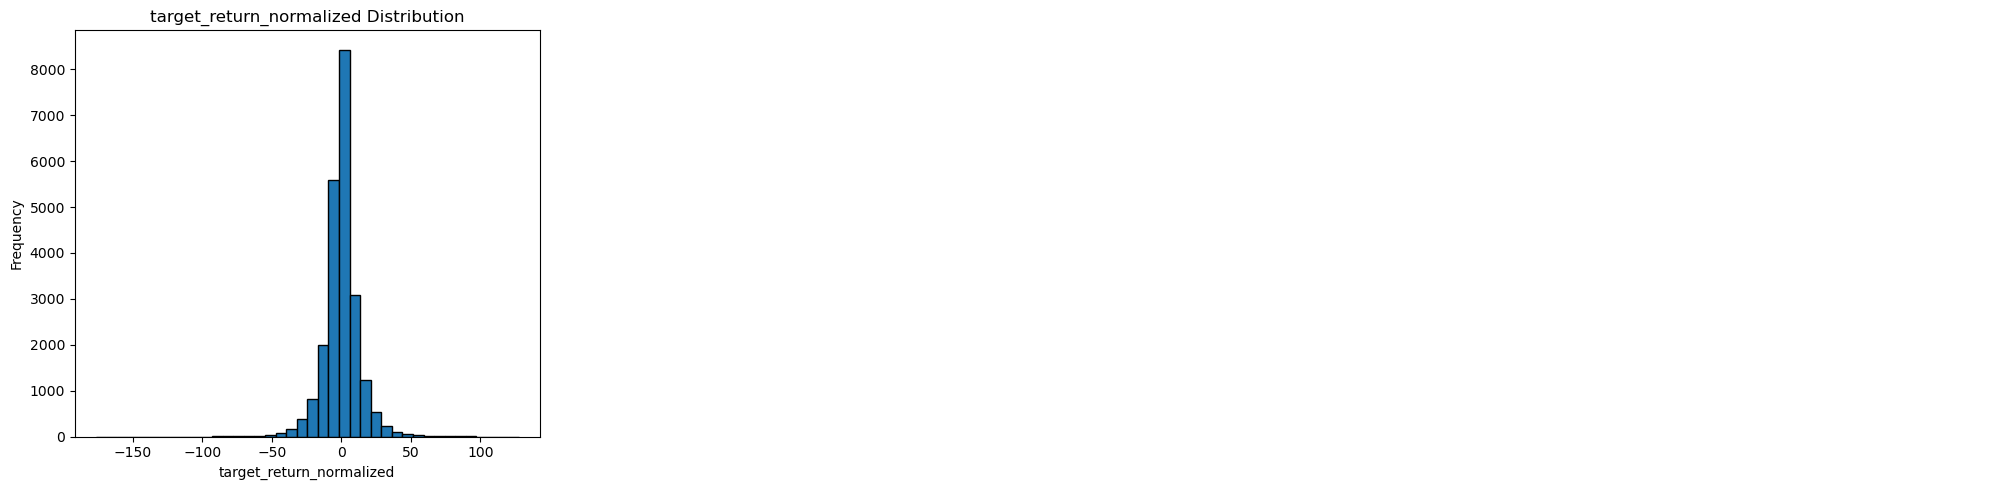

In [240]:
target_df = ob_stv(grouped_df, hyper_paras)
dist_plot(target_df, [hyper_paras.target])

# target_limit = 50
# target_df = target_df.filter(
#         pl.col(hyper_paras.target).abs() <= 50,
#     )

                               OLS Regression Results                               
Dep. Variable:     target_return_normalized   R-squared:                       0.037
Model:                                  OLS   Adj. R-squared:                  0.037
Method:                       Least Squares   F-statistic:                     174.1
Date:                      Tue, 08 Apr 2025   Prob (F-statistic):          2.02e-182
Time:                              21:33:10   Log-Likelihood:                -89489.
No. Observations:                     22798   AIC:                         1.790e+05
Df Residuals:                         22792   BIC:                         1.790e+05
Df Model:                                 5                                         
Covariance Type:                  nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

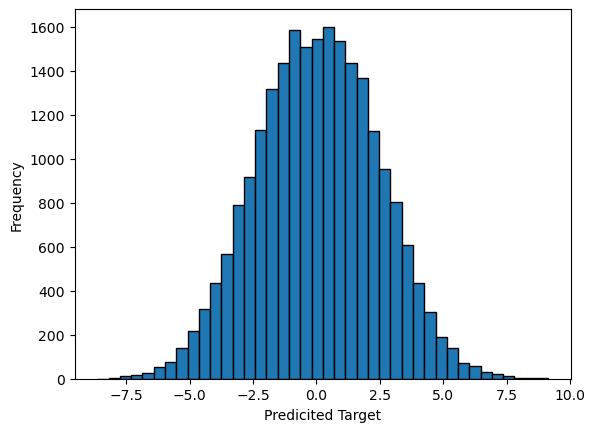

In [242]:
lr_df = linreg(target_df, avg_zscore_df, hyper_paras)

                               OLS Regression Results                               
Dep. Variable:     target_return_normalized   R-squared:                       0.018
Model:                                  OLS   Adj. R-squared:                  0.018
Method:                       Least Squares   F-statistic:                     104.7
Date:                      Tue, 08 Apr 2025   Prob (F-statistic):           1.42e-88
Time:                              19:01:21   Log-Likelihood:                -89977.
No. Observations:                     23272   AIC:                         1.800e+05
Df Residuals:                         23267   BIC:                         1.800e+05
Df Model:                                 4                                         
Covariance Type:                  nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

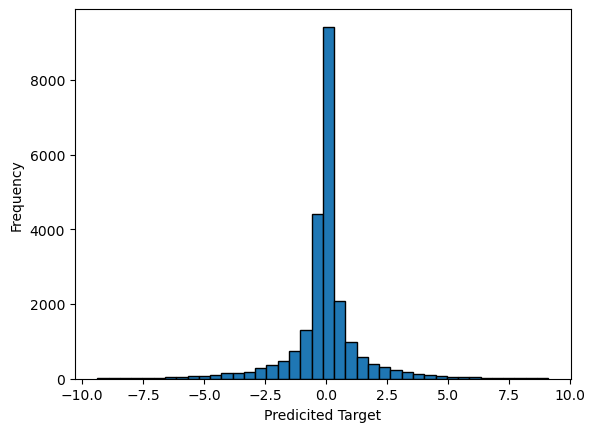

In [120]:
lr_df = linreg(target_df, avg_zscore_df, hyper_paras)

In [121]:
lr_df

bucket_id,target_return_normalized,buy_slippage,sell_slippage,buy_volume,sell_volume
i32,f64,f64,f64,f64,f64
444,-3.908842,-0.218822,0.243616,-0.301938,-0.213539
460,-8.955312,-0.30765,-0.09384,-0.343322,-0.177729
510,3.099697,-0.292397,0.301989,-0.281013,-0.242896
586,-1.83056,-0.135878,0.312149,-0.101339,-0.256186
670,-3.20553,-0.227249,0.294364,-0.139746,-0.259377
…,…,…,…,…,…
2033838,-3.113122,-0.315719,-7.756923,-0.34252,0.29614
2033895,12.518957,0.377646,0.196036,1.656778,-0.335129
2034115,3.64822,-0.171519,0.168932,-0.395316,-0.216861


In [45]:
lr_df.drop('bucket_id').corr()

target_return_normalized,vwap,buy_slippage,sell_slippage,buy_count,buy_volume,sell_volume
f64,f64,f64,f64,f64,f64,f64
1.0,-0.063626,-0.089016,-0.081489,-0.159156,-0.087148,0.091732
-0.063626,1.0,0.065708,0.052138,0.143143,0.04172,-0.045121
-0.089016,0.065708,1.0,0.096571,0.326496,0.475177,-0.125393
-0.081489,0.052138,0.096571,1.0,0.323045,0.124563,-0.482845
-0.159156,0.143143,0.326496,0.323045,1.0,0.415694,-0.409802
-0.087148,0.04172,0.475177,0.124563,0.415694,1.0,-0.160641
0.091732,-0.045121,-0.125393,-0.482845,-0.409802,-0.160641,1.0


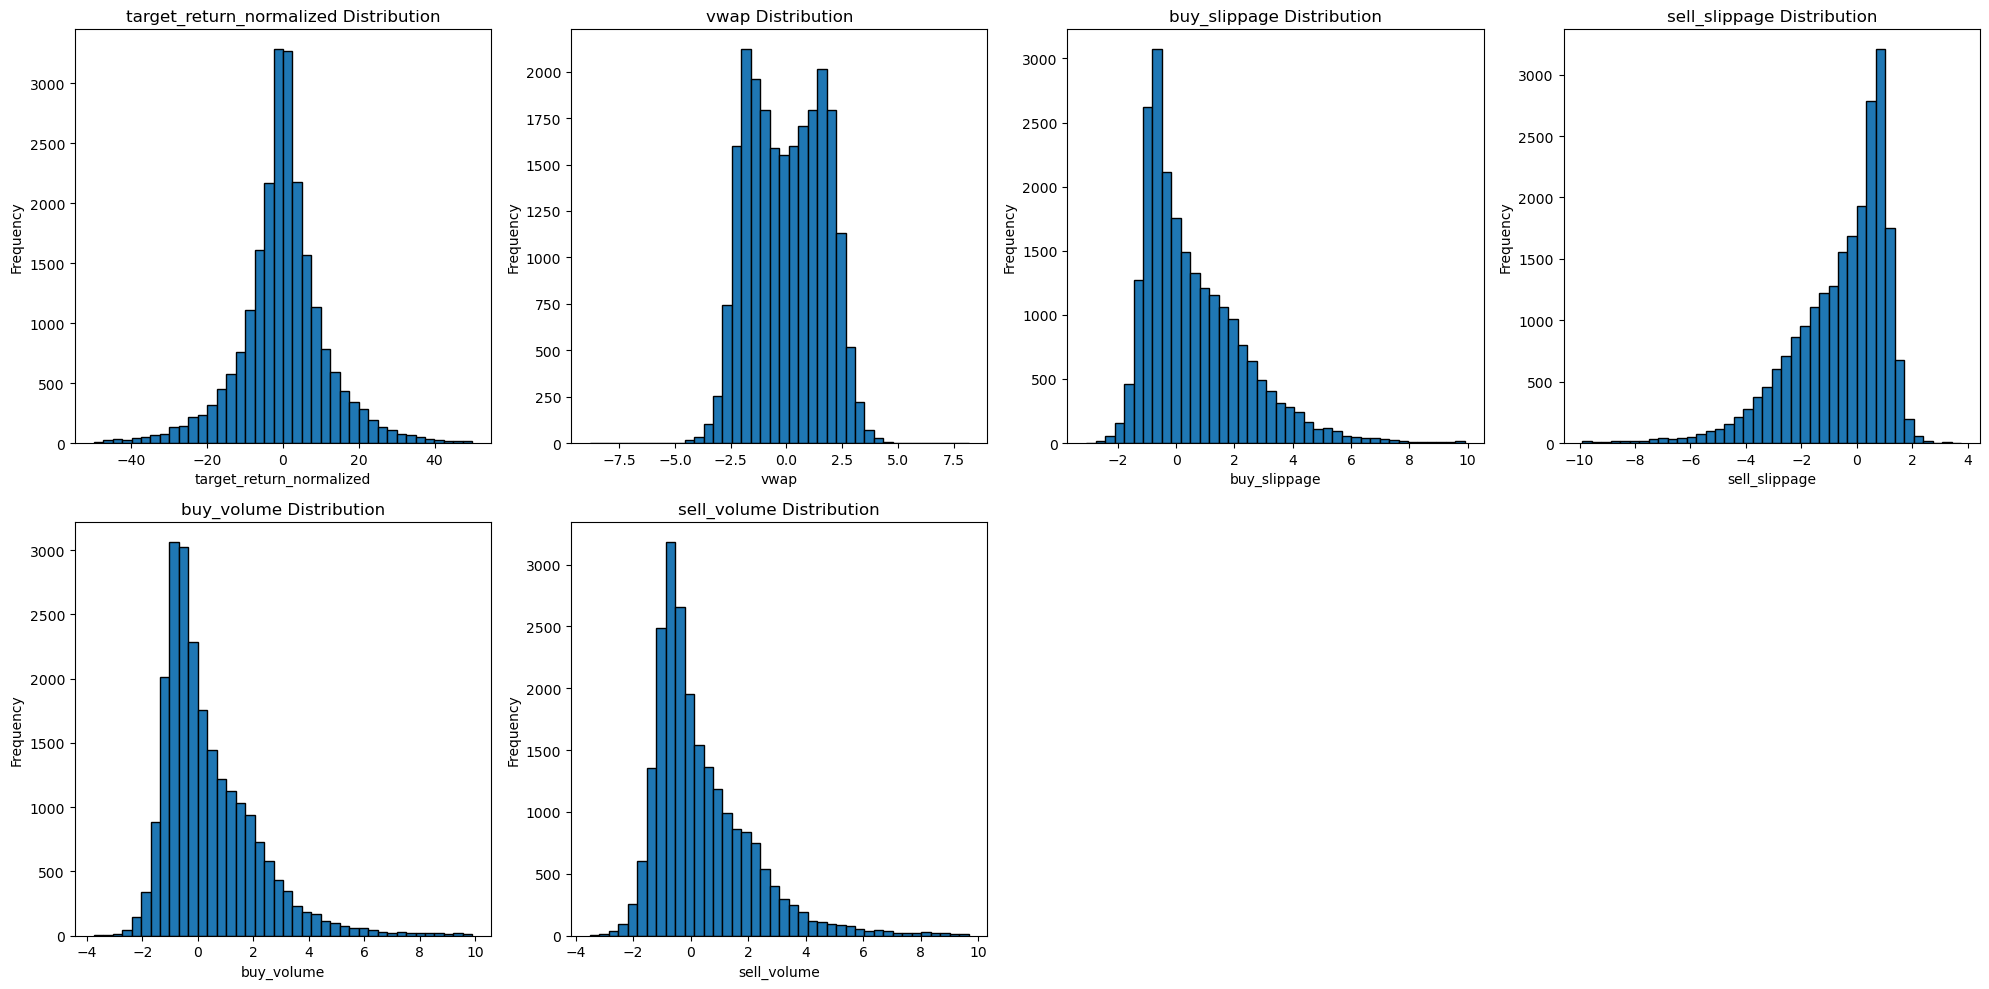

In [244]:
features_plot = ['target_return_normalized', 'vwap', 'buy_slippage', 'sell_slippage', 'buy_volume', 'sell_volume']

dist_plot(lr_df, features_plot, min_value=-50, max_value=50)

In [989]:
hyper_paras = DataProcessParas(
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    price_round = 8,
    volume_round = 8,
    resample_method = 'latency',
    latency_gap = 5_000,
    # When handling perps, it could be higher, while dealing with latency cluster, it should be lower. But also need to adjust vol_window and zscore_window correspondly.
    data_span_days = 3, # Keep the datapoints to be 50-100 (0.5 data_span -> 1 data span) per min. The higher, the more points per min. 50 points seems to be optimal!
    vol_window = 100, # 2mins as vol window, don't change
    
    # Step 4: Calculate aggregation features
    feature_windows = [15, 30, 60, 90, 150], # agg feature window, can consider use average of different window value
    winsorize_features = [],
    winsorize_qtl = 0.99,
    zscore_window = 75, # Compare current agg feature with the past zscore_window sample, seems 150 is a good number, don't change. (i.e. 1.5min)
    
    # Step 5: Observation Sampling and Set Target Variable
    beta_vol = 2,
    fixed_spread = 5,
    blind_spot_us = 40_000,
    offset = -600_000_000, # Used with blind_spot_us together, i.e. past 20ms to 10 min period
    latency_thres = 100_000,
    
    # Step 6: Linear Regression
    target = 'target_return_normalized',
    lr_features = ['buy_vd_z', 'sell_vd_z', 'bcount_z', 'bvolume_z', 'vwap_z'], #['buy_vd_z', , , , ],
    merge_col = 'local_timestamp'
)

TypeError: DataProcessParas.__init__() got an unexpected keyword argument 'resample_method'

volume_threshold: 8.5


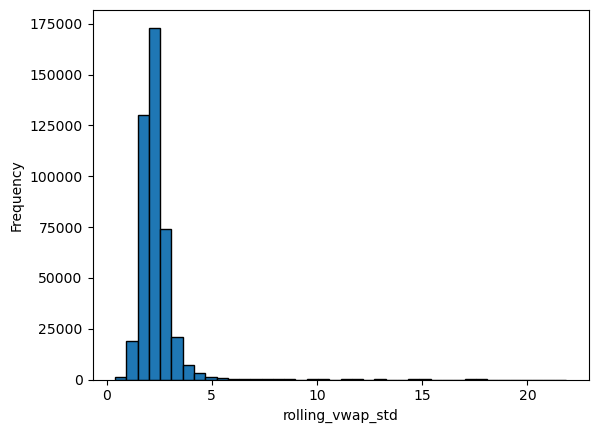

In [4255]:
grouped_df = resample_trades_data(ip_binance_perp, hyper_paras)
filtered_df = filter_trades_data(grouped_df, hyper_paras)
dist_plot(filtered_df, 'rolling_vwap_std')

In [4257]:
avg_zscore_df = pl.DataFrame()
for feature_window in hyper_paras.feature_windows:
    feature_df = agg_feature(filtered_df, hyper_paras, feature_window)
    zscore_df = rolling_zscore(feature_df, hyper_paras)
    
    zscore_df = zscore_df.drop('index')

    if avg_zscore_df.height == 0:
        avg_zscore_df = zscore_df
    else:
        df_joined = avg_zscore_df.join(zscore_df, on="local_timestamp", how="inner", suffix="_df2")
        avg_zscore_df = df_joined.select(
            pl.col("local_timestamp"),
            *[(pl.col(col) + pl.col(f"{col}_df2")).alias(col) for col in avg_zscore_df.columns if col != "local_timestamp"]
        )
        
# Divided by feature windows length
avg_zscore_df = avg_zscore_df.select(
    pl.col("local_timestamp").alias("local_timestamp"),
    *[pl.col(col) / len(hyper_paras.feature_windows) for col in avg_zscore_df.columns if col != "local_timestamp"]
)

# # Doing clipping
# for feature in zscore_df.columns:
#     if feature == 'local_timestamp':
#         continue
#     upper_limit = 3
#     lower_limit = -3
#     avg_zscore_df = avg_zscore_df.with_columns(
#         pl.when(pl.col(feature) >= upper_limit).then(upper_limit)
#         .when(pl.col(feature) <= lower_limit).then(lower_limit)
#         .otherwise(pl.col(feature)).alias(feature),
#     )

prev_length = avg_zscore_df.height

# Doing droping
for feature in zscore_df.columns:
    if feature == 'local_timestamp':
        continue
    upper_limit = 10
    lower_limit = -10
    avg_zscore_df = avg_zscore_df.filter(
        pl.col(feature) <= upper_limit,
        pl.col(feature) >= lower_limit
    )

drop_nums = prev_length - avg_zscore_df.height
print(f'drop {drop_nums} outliers out of {prev_length} samples')

drop 0 outliers out of 433633 samples


volume_threshold: 8.5


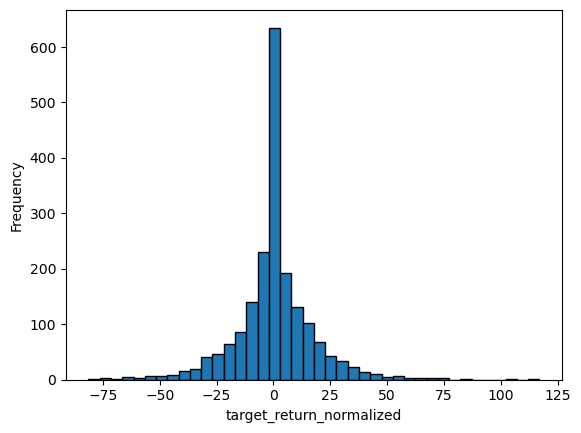

In [4269]:
target_df = ob_stv(grouped_df, hyper_paras)
dist_plot(target_df, hyper_paras.target)

In [4271]:
lr_df = linreg(target_df, avg_zscore_df, hyper_paras)

                               OLS Regression Results                               
Dep. Variable:     target_return_normalized   R-squared:                       0.158
Model:                                  OLS   Adj. R-squared:                  0.156
Method:                       Least Squares   F-statistic:                     73.01
Date:                      Mon, 07 Apr 2025   Prob (F-statistic):           3.38e-70
Time:                              18:01:22   Log-Likelihood:                -8118.9
No. Observations:                      1947   AIC:                         1.625e+04
Df Residuals:                          1941   BIC:                         1.628e+04
Df Model:                                 5                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

#### Download raw data for specific time period

In [ ]:
time = 1742429049008000
btc_trades.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_trades_sample.csv')
btc_ob.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_ob_sample.csv')
btc_bbo.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_bbo_sample.csv')

In [426]:
btc_trades_bn.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{1742429045008000}_btc_trades_sample.csv')